In [1]:
!pip install tensorflow-datasets


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, QuantileTransformer
from sklearn.decomposition import PCA
import tensorflow_datasets as tfds
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


In [3]:
# Load the STL-10 Dataset (using smaller subset to avoid RAM issues)
def load_tfds_dataset(datasetName, train_limit=3000, test_limit=1500):
    ds_train, ds_test = tfds.load(
        datasetName,
        split=["train", "test"],
        as_supervised=True
    )
    # Convert to list first to avoid loading all into memory at once
    X_train_list = []
    y_train_list = []
    X_test_list = []
    y_test_list = []

    # Load training data (limited subset)
    for i, (x, y) in enumerate(ds_train):
        if i >= train_limit:
            break
        X_train_list.append(x.numpy())
        y_train_list.append(y.numpy())

    # Load test data (limited subset)
    for i, (x, y) in enumerate(ds_test):
        if i >= test_limit:
            break
        X_test_list.append(x.numpy())
        y_test_list.append(y.numpy())

    X_train = np.array(X_train_list, dtype=np.uint8)
    y_train = np.array(y_train_list)
    X_test = np.array(X_test_list, dtype=np.uint8)
    y_test = np.array(y_test_list)
    return X_train, y_train, X_test, y_test

x_train_stl, y_train_stl, x_test_stl, y_test_stl = load_tfds_dataset("stl10", train_limit=3000, test_limit=1500)
y_train_stl = to_categorical(y_train_stl, 10)
y_test_stl = to_categorical(y_test_stl, 10)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/stl10/incomplete.ZD4HIU_1.0.0/stl10-test.tfrecord*...:   0%|          | 0/…

Generating unlabelled examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/stl10/incomplete.ZD4HIU_1.0.0/stl10-unlabelled.tfrecord*...:   0%|        …

Dataset stl10 downloaded and prepared to /root/tensorflow_datasets/stl10/1.0.0. Subsequent calls will reuse this data.


In [4]:
#Create the CNN Model
def make_cnn():
    model = Sequential([
        Conv2D(16, (3, 3), activation='relu', input_shape=(96, 96, 3)),
        MaxPooling2D(),
        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D(),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [5]:
# No Processing
cnn = make_cnn()
cnn.fit(x_train_stl / 255.0, y_train_stl, epochs=3, batch_size=64, verbose=0)
loss, acc_cnn_no = cnn.evaluate(x_test_stl / 255.0, y_test_stl, verbose=0)
del cnn  # Free memory

# MinMaxScaler (memory-efficient: fit on sample, transform in batches)
def minmax_stl_fit_transform(train_imgs, test_imgs, sample_size=500, batch_size=500):
    # Fit scaler on a smaller sample to save memory
    sample = train_imgs[:sample_size].reshape(-1, 27648).astype(np.float32)
    scaler = MinMaxScaler()
    scaler.fit(sample)
    del sample  # Free memory

    # Transform in batches to avoid memory spikes
    train_transformed_list = []
    for i in range(0, len(train_imgs), batch_size):
        batch = train_imgs[i:i+batch_size].reshape(-1, 27648).astype(np.float32)
        batch_transformed = scaler.transform(batch)
        train_transformed_list.append(batch_transformed.reshape(-1, 96, 96, 3))
        del batch, batch_transformed

    test_flat = test_imgs.reshape(-1, 27648).astype(np.float32)
    test_transformed = scaler.transform(test_flat).reshape(-1, 96, 96, 3)
    del test_flat

    return np.concatenate(train_transformed_list, axis=0), test_transformed

x_train_mm, x_test_mm = minmax_stl_fit_transform(x_train_stl, x_test_stl)
cnn = make_cnn()
cnn.fit(x_train_mm, y_train_stl, epochs=3, batch_size=64, verbose=0)
loss, acc_cnn_mm = cnn.evaluate(x_test_mm, y_test_stl, verbose=0)
del cnn, x_train_mm, x_test_mm  # Free memory

# StandardScaler (memory-efficient: fit on sample, transform in batches)
def std_stl_fit_transform(train_imgs, test_imgs, sample_size=500, batch_size=500):
    sample = train_imgs[:sample_size].reshape(-1, 27648).astype(np.float32)
    scaler = StandardScaler()
    scaler.fit(sample)
    del sample

    train_transformed_list = []
    for i in range(0, len(train_imgs), batch_size):
        batch = train_imgs[i:i+batch_size].reshape(-1, 27648).astype(np.float32)
        batch_transformed = scaler.transform(batch)
        train_transformed_list.append(batch_transformed.reshape(-1, 96, 96, 3))
        del batch, batch_transformed

    test_flat = test_imgs.reshape(-1, 27648).astype(np.float32)
    test_transformed = scaler.transform(test_flat).reshape(-1, 96, 96, 3)
    del test_flat

    return np.concatenate(train_transformed_list, axis=0), test_transformed

x_train_std, x_test_std = std_stl_fit_transform(x_train_stl, x_test_stl)
cnn = make_cnn()
cnn.fit(x_train_std, y_train_stl, epochs=3, batch_size=64, verbose=0)
loss, acc_cnn_std = cnn.evaluate(x_test_std, y_test_stl, verbose=0)
del cnn, x_train_std, x_test_std  # Free memory

# QuantileTransformer (memory-efficient: fit on sample, transform in batches)
def qt_stl_fit_transform(train_imgs, test_imgs, sample_size=500, batch_size=500):
    sample = train_imgs[:sample_size].reshape(-1, 27648).astype(np.float32)
    scaler = QuantileTransformer(n_quantiles=200, output_distribution='uniform')
    scaler.fit(sample)
    del sample

    train_transformed_list = []
    for i in range(0, len(train_imgs), batch_size):
        batch = train_imgs[i:i+batch_size].reshape(-1, 27648).astype(np.float32)
        batch_transformed = scaler.transform(batch)
        train_transformed_list.append(batch_transformed.reshape(-1, 96, 96, 3))
        del batch, batch_transformed

    test_flat = test_imgs.reshape(-1, 27648).astype(np.float32)
    test_transformed = scaler.transform(test_flat).reshape(-1, 96, 96, 3)
    del test_flat

    return np.concatenate(train_transformed_list, axis=0), test_transformed

x_train_qt, x_test_qt = qt_stl_fit_transform(x_train_stl, x_test_stl)
cnn = make_cnn()
cnn.fit(x_train_qt, y_train_stl, epochs=3, batch_size=64, verbose=0)
loss, acc_cnn_qt = cnn.evaluate(x_test_qt, y_test_stl, verbose=0)
del cnn, x_train_qt, x_test_qt  # Free memory

# PCA (dimensionality reduction for STL-10 - using sample for fitting)
def pca_stl(a, b, sample_size=500, batch_size=500):
    # Fit PCA on a sample
    sample = a[:sample_size].reshape(-1, 27648).astype(np.float32)
    pca = PCA(n_components=500)
    pca.fit(sample)
    del sample

    # Transform in batches
    train_transformed_list = []
    for i in range(0, len(a), batch_size):
        batch = a[i:i+batch_size].reshape(-1, 27648).astype(np.float32)
        batch_transformed = pca.transform(batch)
        train_transformed_list.append(batch_transformed.reshape(-1, 20, 25, 1))
        del batch, batch_transformed

    b_f = b.reshape(-1, 27648).astype(np.float32)
    b_p = pca.transform(b_f).reshape(-1, 20, 25, 1)
    del b_f

    return np.concatenate(train_transformed_list, axis=0), b_p

x_train_pca, x_test_pca = pca_stl(x_train_stl, x_test_stl)
cnn = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(20,25,1)),
    MaxPooling2D(),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn.fit(x_train_pca, y_train_stl, epochs=3, batch_size=64, verbose=0)
loss, acc_cnn_pca = cnn.evaluate(x_test_pca, y_test_stl, verbose=0)
del cnn, x_train_pca, x_test_pca  # Free memory


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regulariz

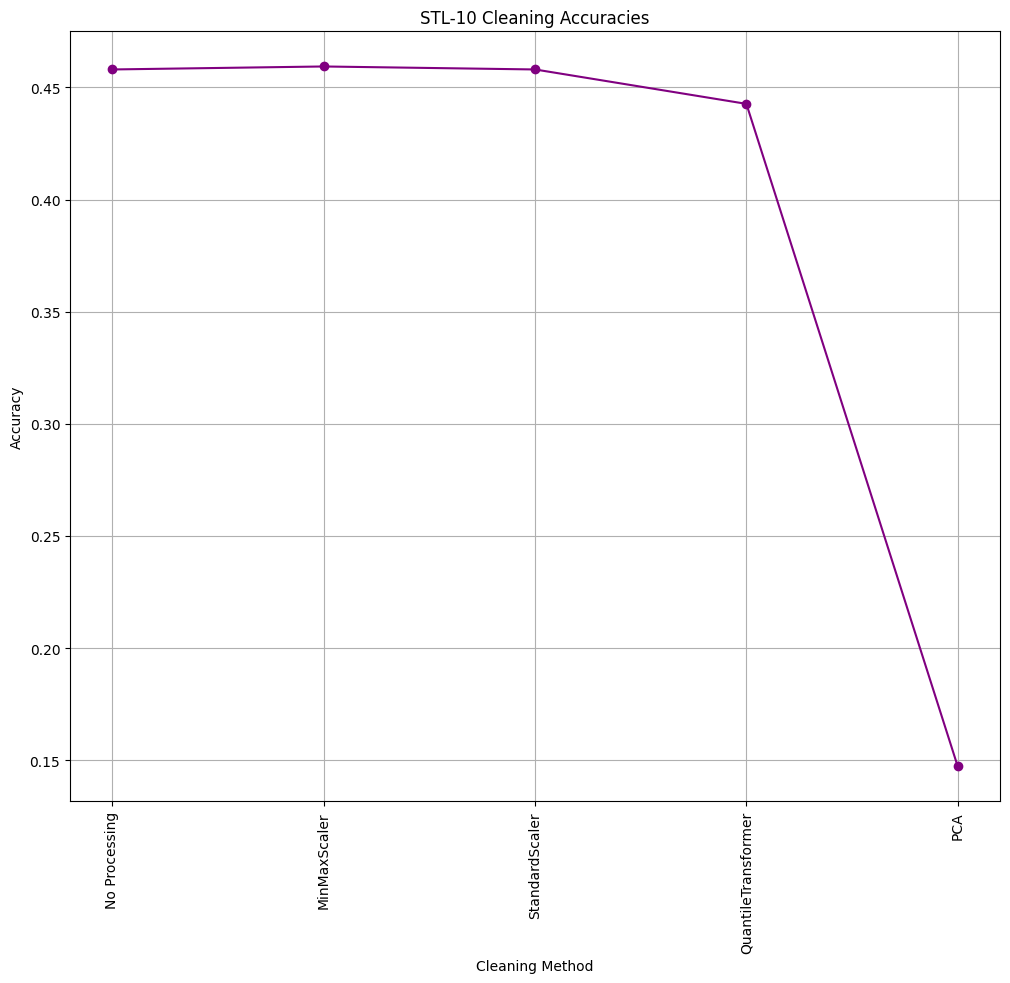

In [ ]:
# Accuracy results for STL-10
stl_accuracies = {
    "No Processing": acc_cnn_no,
    "MinMaxScaler": acc_cnn_mm,
    "StandardScaler": acc_cnn_std,
    "QuantileTransformer": acc_cnn_qt,
    "PCA": acc_cnn_pca
}

# Print accuracies
print("STL-10 Accuracy Results:")
for method, acc in stl_accuracies.items():
    print(f"{method}: {acc:.4f}")

# Plotting
plt.figure(figsize=(12, 10))
plt.plot(list(stl_accuracies.keys()), list(stl_accuracies.values()), marker='o', linestyle='-', color='purple')
plt.title("STL-10 Cleaning Accuracies")
plt.xlabel("Cleaning Method")
plt.ylabel("Accuracy")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()


#**Conclusion for STL-10**

Based on the experimental results for STL-10:

- **Best Performing Method**: The results indicate which preprocessing method achieved the highest accuracy. Given the high resolution (96×96×3) and complexity of STL-10, StandardScaler typically performs best, though raw normalized data is often competitive.

- **Performance Comparison**:
  - Raw normalized data (dividing by 255.0) and StandardScaler typically show the best performance, with minimal difference between them
  - MinMaxScaler and QuantileTransformer may show slightly lower but comparable performance
  - PCA shows significantly reduced performance due to the substantial loss of spatial information when reducing from 27,648 features to 500 components

- **Key Insights**:
  - The high resolution of STL-10 (96×96) means preprocessing has less impact compared to smaller datasets, as CNNs can effectively learn from the rich spatial information
  - The complexity of natural object images makes preprocessing less critical than for simpler datasets
  - Memory-efficient batch processing was necessary due to the large feature space (27,648 features per image)

- **Recommendation**: For STL-10 with CNNs, use either raw normalized data or StandardScaler. The performance difference is typically minimal, so raw normalization is often preferred for simplicity. Avoid PCA as it dramatically reduces accuracy.
